In [8]:
"""
Notebook: model_avanced_v1.ipynb
Objetivo: Entrenamiento de modelos avanzadoS de ML para detección de diabetes
basado en el dataset BRFSS2015 del CDC.
Autor: Jesús Rodríguez
Fecha: 17/11/2025
"""

'\nNotebook: model_avanced_v1.ipynb\nObjetivo: Entrenamiento de modelos avanzadoS de ML para detección de diabetes\nbasado en el dataset BRFSS2015 del CDC.\nAutor: Jesús Rodríguez\nFecha: 17/11/2025\n'

## 1. Configuración inicial


In [9]:
# Librerías básicas
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    precision_recall_curve, auc, confusion_matrix, RocCurveDisplay
)

# Modelos externos
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Interpretabilidad
from IPython.display import display
import shap

# Google Drive (solo necesario si se ejecuta en Colab)
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [10]:
# Carpeta y archivo de datos
data_dir = Path("data")  # ruta relativa para ejecución local
DATA_FILE = "cleaned_dataset.csv"
DATA_PATH = data_dir / DATA_FILE

# Montaje de Drive solo en Colab si el archivo no existe localmente
if IN_COLAB and not DATA_PATH.exists():
    drive.mount("/content/drive")
    data_dir = Path("/content/drive/MyDrive/TFM/data")
    DATA_PATH = data_dir / DATA_FILE

# Crear carpeta local si no existe
data_dir.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Verificar que el dataset exista
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} no existe. "
        f"Coloca el archivo en '{data_dir}' o monta Drive en Colab."
    )

# Carga del dataset
df = pd.read_csv(DATA_PATH, encoding="Latin-1")

## 2. Exploración inicial del dataset

In [12]:
# Dimensiones y tipos
print("Dimensiones del dataset:", df.shape)
print(df.info())

# Distribución inicial de DIABETE3
print("Distribución original del target:")
print(df["DIABETE3"].value_counts(normalize=True))

Dimensiones del dataset: (257709, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-null  float64
 18  _AGEG5YR  257709 non-null  float64
 19  _BMI5C

Distribución del target tras normalización:
DIABETE3
0    229318
1     28391
Name: count, dtype: int64


/tmp/ipython-input-1411977993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


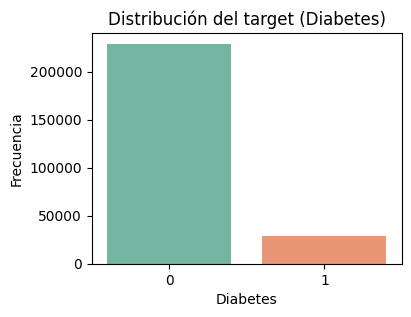

In [13]:
# Normalización del target: 1 → Diabetes, 0 → No Diabetes
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0})

# Comprobación
print("Distribución del target tras normalización:")
print(df["DIABETE3"].value_counts())

# Visualización
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución del target (Diabetes)")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.show()

## 3. Análisis Exploratorio de Datos (EDA)

El EDA completo por grupos de las variables se realizó en model_base_v1.ipynb

## 4. División del dataset

In [14]:
# pylint: disable=C0103
# pylint: disable=W0621
# Las variables de entrenamiento/validación/test usan nombres clásicos de ML:
# X_train, y_train, X_val, X_test, etc.

# Target
TARGET = "DIABETE3"

# Separación de features y target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# División: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 5. Pipelines de preprocesamiento

### 5.1. Separación por tipo de variable

In [15]:
# Variables nominales con varias categorías (para OneHot en RF)
CATEGORICAL_NOMINAL = ['BPHIGH4', '_RACE']

# Variables binarias (imputación 0/1 en determinista)
BINARY_VARS = ['BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
               'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK',
               'DIFFALON', 'DIFFDRES', 'SMOKE100', 'ADDEPEV2', 'SEX']

# Variables ordinales
CATEGORICAL_ORDINAL = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']

# Variables numéricas
NUMERIC_VARS = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']

### 5.2. Preprocesamiento determinista

In [16]:
def rf_deterministic_preproc(X_input):
    """
    Preprocesamiento determinista para modelos Random Forest.

    - Sustituye los valores codificados como -1 por NaN.
    - Convierte las variables binarias a formato 0/1,
      asignando 0 a los valores distintos de 1.

    Args:
        X_input (pd.DataFrame): Dataset de entrada.

    Returns:
        pd.DataFrame: Dataset preprocesado.
    """
    X = X_input.copy()

    # Reemplazo global de valores -1 por NaN
    X = X.replace(-1, np.nan)

    # Normalización de variables binarias
    for col in BINARY_VARS:
        X[col] = (X[col] == 1).astype(int)

    return X


def boosting_deterministic_preproc(X_input):
    """
    Preprocesamiento determinista para modelos de boosting
    (XGBoost / LightGBM).

    - Sustituye los valores codificados como -1 por NaN.
    - Convierte las variables binarias a formato 0/1.
    - Convierte las variables nominales a tipo 'category'.

    Args:
        X_input (pd.DataFrame): Dataset de entrada.

    Returns:
        pd.DataFrame: Dataset preprocesado.
    """
    X = X_input.copy()

    # Reemplazo global de valores -1 por NaN
    X = X.replace(-1, np.nan)

    # Normalización de variables binarias
    for col in BINARY_VARS:
        X[col] = (X[col] == 1).astype(int)

    # Conversión de variables nominales a categóricas
    for col in CATEGORICAL_NOMINAL:
        X[col] = X[col].astype('category')

    return X

### 5.3. Preprocesamiento numérico (Capping de outliers)

In [17]:
def cap_outliers_numeric(X_input, numeric_vars):
    """
    Recorta valores extremos de variables numéricas al percentil 1 y 99.

    Args:
        X_input (pd.DataFrame): Dataset de entrada.
        numeric_vars (list): Lista de columnas numéricas a recortar.

    Returns:
        pd.DataFrame: Dataset con valores acotados.
    """
    X = X_input.copy()
    for col in numeric_vars:
        low = np.nanpercentile(X[col], 1)
        high = np.nanpercentile(X[col], 99)
        X[col] = X[col].clip(low, high)
    return X

### 5.4. Transformadores por tipo de variable

In [18]:
# Nominal RF: Most frequent + OneHot
nominal_pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Nominal Boosting: Most frequent
nominal_pipeline_boosting = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Ordinal: Most frequent
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Numéricas: capping + median
numeric_pipeline = Pipeline(steps=[
    ('cap_outliers', FunctionTransformer(
        func=cap_outliers_numeric,
        kw_args={'numeric_vars': NUMERIC_VARS},
        validate=False
    )),
    ('imputer', SimpleImputer(strategy='median'))
])

### 5.5. ColumnTransformers

In [19]:
# ColumnTransformer para RF
preprocessor_rf = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline_rf, CATEGORICAL_NOMINAL),
    ('bin', 'passthrough', BINARY_VARS),  # Ya procesadas en determinista
    ('ord', ordinal_transformer, CATEGORICAL_ORDINAL),
    ('num', numeric_pipeline, NUMERIC_VARS)
])

# ColumnTransformer para XGB/LightGBM
preprocessor_boosting = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline_boosting, CATEGORICAL_NOMINAL),
    ('bin', 'passthrough', BINARY_VARS),
    ('ord', ordinal_transformer, CATEGORICAL_ORDINAL),
    ('num', numeric_pipeline, NUMERIC_VARS)
])

## 6. Definición de modelos

### 6.1. Modelos individuales

In [20]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=0.89/0.11,
    eval_metric='logloss',
    random_state=42
)

# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    num_leaves=31,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

### 6.2. Pipelines finales por modelo

In [21]:
models = {
    'Random Forest': Pipeline([
        ('deterministic', FunctionTransformer(rf_deterministic_preproc)),
        ('preprocessor', preprocessor_rf),
        ('model', rf_model)
    ]),
    'XGBoost': Pipeline([
        ('deterministic', FunctionTransformer(boosting_deterministic_preproc)),
        ('preprocessor', preprocessor_boosting),
        ('model', xgb_model)
    ]),
    'LightGBM': Pipeline([
        ('deterministic', FunctionTransformer(boosting_deterministic_preproc)),
        ('preprocessor', preprocessor_boosting),
        ('model', lgb_model)
    ])
}

### 6.3. Configuración de validación cruzada

In [22]:
# Estratificación para mantener proporción de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas a calcular
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'       # PR-AUC, útil en dataset desbalanceado
}

### 6.4. Evaluación de modelos mediante cross-validation

In [ ]:
cv_results = []

for model_name, pipeline in models.items():
    # cross_validate devuelve dict con test_roc_auc y test_pr_auc
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'Model': model_name,
        'ROC-AUC (CV mean)': scores['test_roc_auc'].mean(),
        'PR-AUC (CV mean)': scores['test_pr_auc'].mean(),
        'ROC-AUC (CV std)': scores['test_roc_auc'].std()
    })

# Resultados en DataFrame
df_cv = pd.DataFrame(cv_results)

print("=== VALIDACIÓN CRUZADA ===")
display(df_cv)

# Selección del mejor modelo según PR-AUC
best_model_name = (
    df_cv.sort_values('PR-AUC (CV mean)', ascending=False)
    .iloc[0]['Model']
)
print(f"Mejor modelo según PR-AUC: {best_model_name}")

## 7. Entrenamiento y evaluación

### 7.1. Preparación de conjuntos de validación y test

In [ ]:
# Asegura que X_val y X_test sean DataFrames con mismos nombres y
# orden de columnas que X_train
X_val = pd.DataFrame(X_val, columns=X_train.columns)
X_test = pd.DataFrame(X_test, columns=X_train.columns)

# Diccionarios para almacenar predicciones y probabilidades
y_prob_val_dict = {}
y_prob_test_dict = {}

# Listas para resultados de métricas
results_val = []
results_test = []

### 7.2. Entrenamiento de modelos y cálculo de métricas (Val/Test)

In [ ]:
for model_name, pipeline in models.items():
    # Entrenamiento
    pipeline.fit(X_train, y_train)

    # Predicciones probabilísticas
    y_prob_val = pipeline.predict_proba(X_val)[:, 1]
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]

    # Almacenamiento para reutilización
    y_prob_val_dict[model_name] = y_prob_val
    y_prob_test_dict[model_name] = y_prob_test

    # Curvas Precision-Recall
    precision_val, recall_val, _ = precision_recall_curve(y_val, y_prob_val)
    precision_test, recall_test, _ = precision_recall_curve(y_test, y_prob_test)

    # Métricas ROC-AUC y PR-AUC
    results_val.append({
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_val, y_prob_val),
        'PR-AUC': auc(recall_val, precision_val)
    })
    results_test.append({
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_test, y_prob_test),
        'PR-AUC': auc(recall_test, precision_test)
    })

# Resultados en DataFrame
df_val_results = pd.DataFrame(results_val)
df_test_results = pd.DataFrame(results_test)

print("=== Métricas (Validación) ===")
display(df_val_results)

print("=== Métricas (Test) ===")
display(df_test_results)

### 7.3. Curvas ROC (Discriminación global del modelo)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, model_name in enumerate(models):
    # Validación
    RocCurveDisplay.from_predictions(
        y_val, y_prob_val_dict[model_name],
        name=f"{model_name} (Val)", ax=axes[0, idx]
    )
    axes[0, idx].set_title(f'{model_name} - ROC (Val)')

    # Test
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test_dict[model_name],
        name=f"{model_name} (Test)", ax=axes[1, idx]
    )
    axes[1, idx].set_title(f'{model_name} - ROC (Test)')

plt.tight_layout()
plt.show()

### 7.4. Curvas Precision–Recall

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, model_name in enumerate(models):
    # Validación
    precision_val, recall_val, _ = precision_recall_curve(
        y_val, y_prob_val_dict[model_name]
    )
    axes[0, idx].plot(recall_val, precision_val, label=f'{model_name} (Val)')
    axes[0, idx].set_xlabel('Recall')
    axes[0, idx].set_ylabel('Precision')
    axes[0, idx].set_title(f'{model_name} - PR Curve (Val)')
    axes[0, idx].legend()

    # Test
    precision_test, recall_test, _ = precision_recall_curve(
        y_test, y_prob_test_dict[model_name]
    )
    axes[1, idx].plot(recall_test, precision_test, label=f'{model_name} (Test)')
    axes[1, idx].set_xlabel('Recall')
    axes[1, idx].set_ylabel('Precision')
    axes[1, idx].set_title(f'{model_name} - PR Curve (Test)')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

### 7.5. Selección de threshold óptimo (Fβ con β=2)

In [ ]:
optimal_thresholds = {}
beta = 2  # Prioriza recall sobre precision

for model_name in models:
    precision, recall, thresholds = precision_recall_curve(
        y_val, y_prob_val_dict[model_name]
    )
    fbeta_scores = (1 + beta**2) * (precision * recall) / (
        (beta**2 * precision) + recall + 1e-9
    )
    best_idx = np.argmax(fbeta_scores)
    optimal_thresholds[model_name] = thresholds[best_idx]

print("Threshold óptimo por modelo (Fβ, β=2):")
print(optimal_thresholds)

### 7.6. Matrices de confusión (Test set)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(models):
    threshold = optimal_thresholds[model_name]
    y_pred_test = (y_prob_test_dict[model_name] >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_test)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{model_name} - Confusion Matrix (Test)')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 7.7. Resultados finales con threshold óptimo

In [ ]:
final_results = []

for name in models:
    threshold = optimal_thresholds[name]
    y_pred_test = (y_prob_test_dict[name] >= threshold).astype(int)

    precision, recall, _ = precision_recall_curve(
        y_test, y_prob_test_dict[name]
    )

    final_results.append({
        'Model': name,
        'Threshold': threshold,
        'Recall': recall_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'F1-score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test_dict[name]),
        'PR-AUC': auc(recall, precision)
    })

df_final_results = pd.DataFrame(final_results)
display(df_final_results)

## 8. Feature Importance (LightGBM)

In [ ]:
def get_feature_names(ct):
    """
    Extrae los nombres de las features de un ColumnTransformer,
    incluyendo los generados por OneHotEncoder si está presente.
    """
    names = []

    for _, transformer, columns in ct.transformers_:
        try:
            # Intentar obtener los nombres generados por el transformador
            names.extend(transformer.get_feature_names_out(columns))
        except AttributeError:
            # Si el transformador no tiene get_feature_names_out,
            # se mantienen los nombres originales
            names.extend(columns)

    return names

In [ ]:
# Obtención del modelo y el preprocesador del pipeline
lgb_model = models['LightGBM'].named_steps['model']
preprocessor = models['LightGBM'].named_steps['preprocessor']

# Obtención de los nombres de las features
feature_names = get_feature_names(preprocessor)

# Construcción del DataFrame con las importancias de las features
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': lgb_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Selección de las 10 variables más importantes y se resetea el índice
importance_df = importance_df.head(10).reset_index(drop=True)

display(importance_df)

## 9. SHAP (SHapley Additive exPlanations)

In [ ]:
# Transformación del dataset de test con el preprocesador
X_test_transformed = models['LightGBM'].named_steps['preprocessor'].transform(X_test)

In [ ]:
# Explainer Tree para LightGBM
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Resumen global de SHAP
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)